In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

df = pd.read_csv("Loan_Default.csv")

# Basic Exploration

In [2]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (255347, 18)

Column Names:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

Data Types:
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

Missing Values:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio   

# Statistical summary

In [3]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


# Explore the target variable

In [4]:
print("Loan Default Distribution:")
print(df["Default"].value_counts())

print("\nPercentage Distribution:")
print(df["Default"].value_counts(normalize=True) * 100)

Loan Default Distribution:
Default
0    225694
1     29653
Name: count, dtype: int64

Percentage Distribution:
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


# Target Visualization

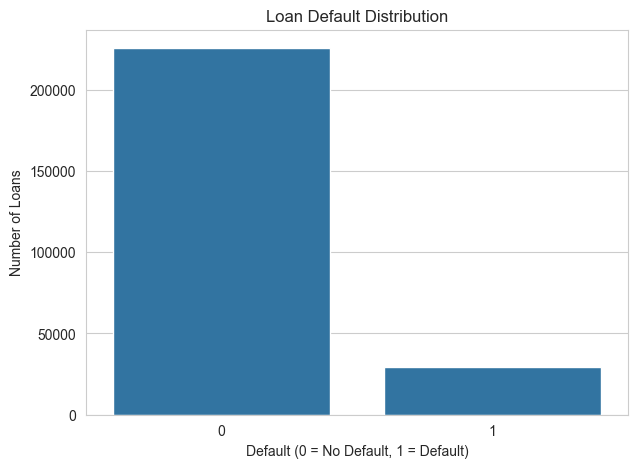

In [5]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Default")

plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No Default, 1 = Default)")
plt.ylabel("Number of Loans")

plt.show()

# Check unique values

In [6]:
categorical_columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 Education
["Bachelor's" "Master's" 'High School' 'PhD']

 EmploymentType
['Full-time' 'Unemployed' 'Self-employed' 'Part-time']

 MaritalStatus
['Divorced' 'Married' 'Single']

 HasMortgage
['Yes' 'No']

 HasDependents
['Yes' 'No']

 LoanPurpose
['Other' 'Auto' 'Business' 'Home' 'Education']

 HasCoSigner
['Yes' 'No']


# Check numeric variables

In [7]:
numerical_columns = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio"
]

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9


# Numerical Distributions

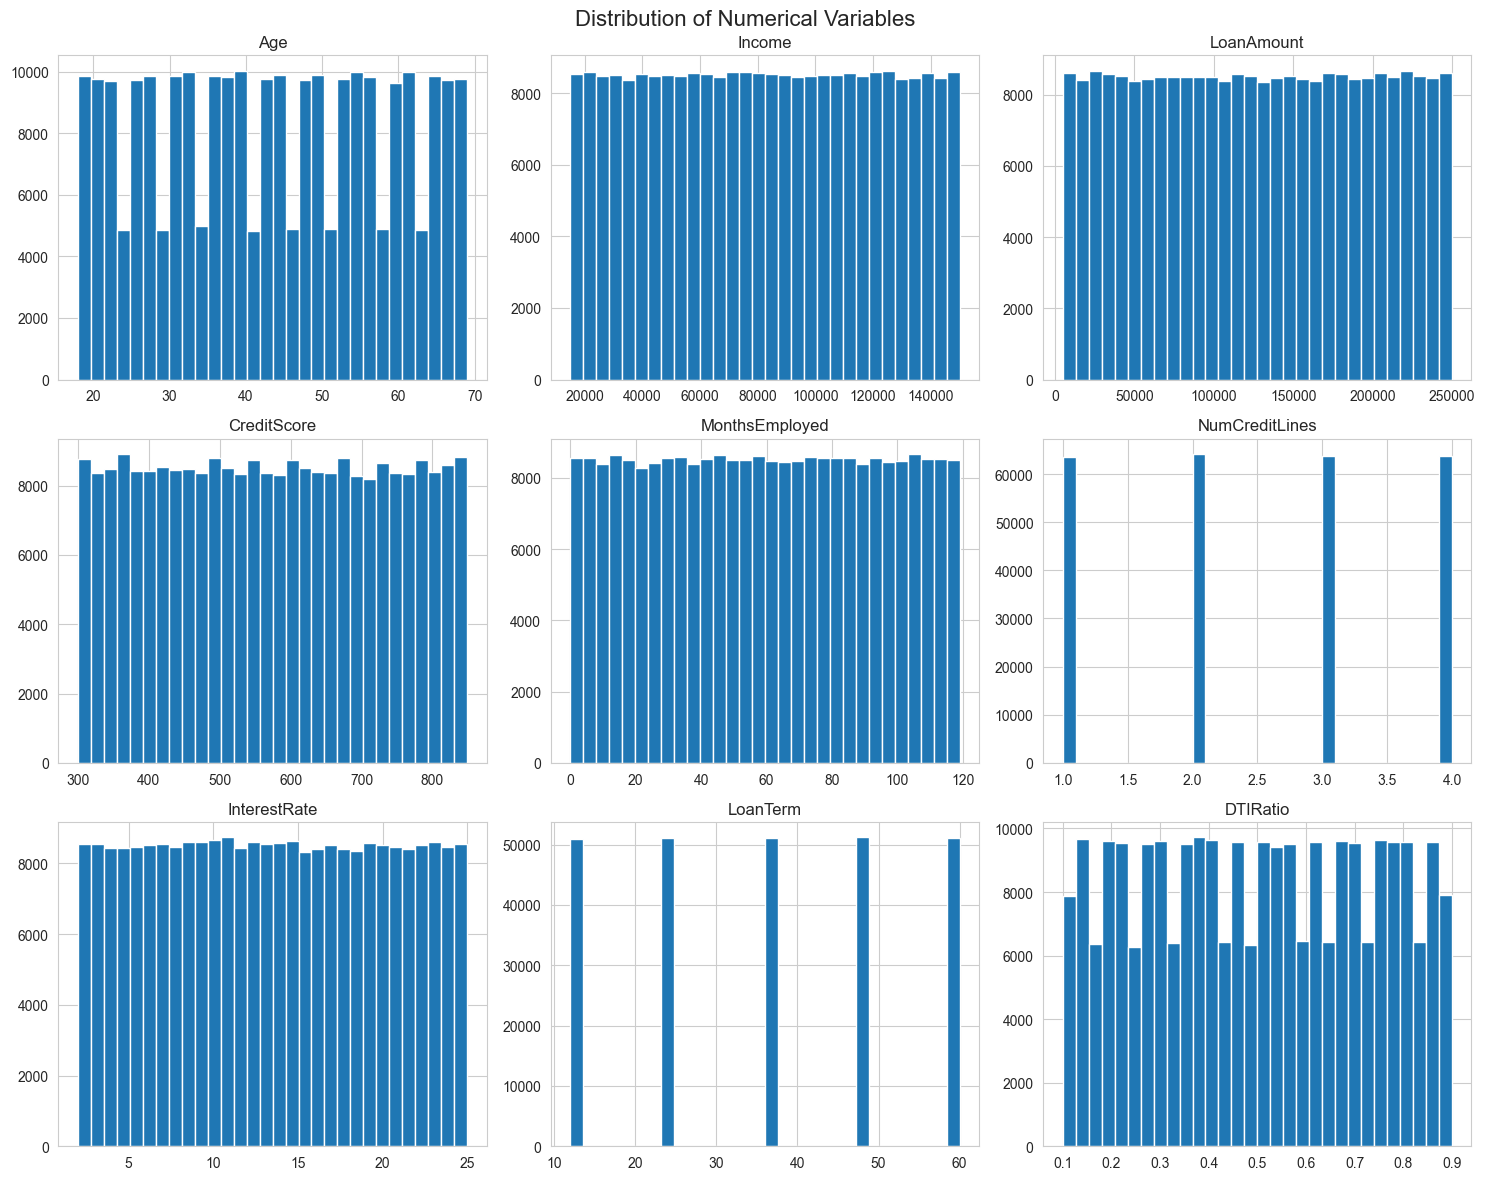

In [8]:
df[numerical_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

# Correlation Heatmap

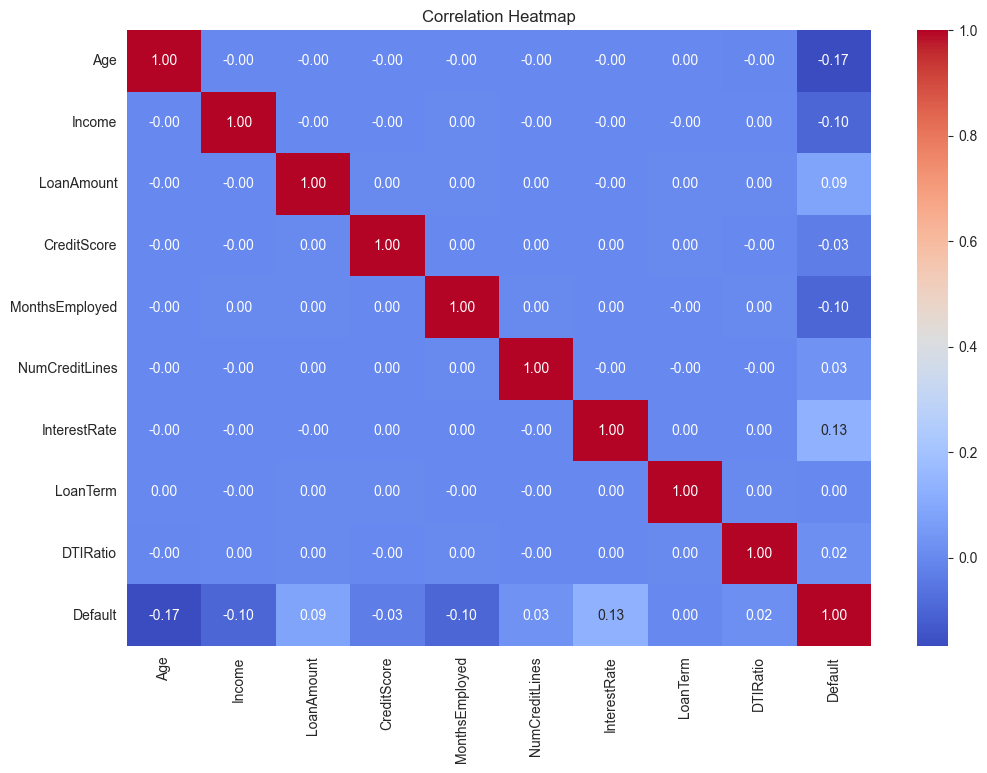

In [9]:
plt.figure(figsize=(12, 8))

correlation = df[numerical_columns + ["Default"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Check outliers

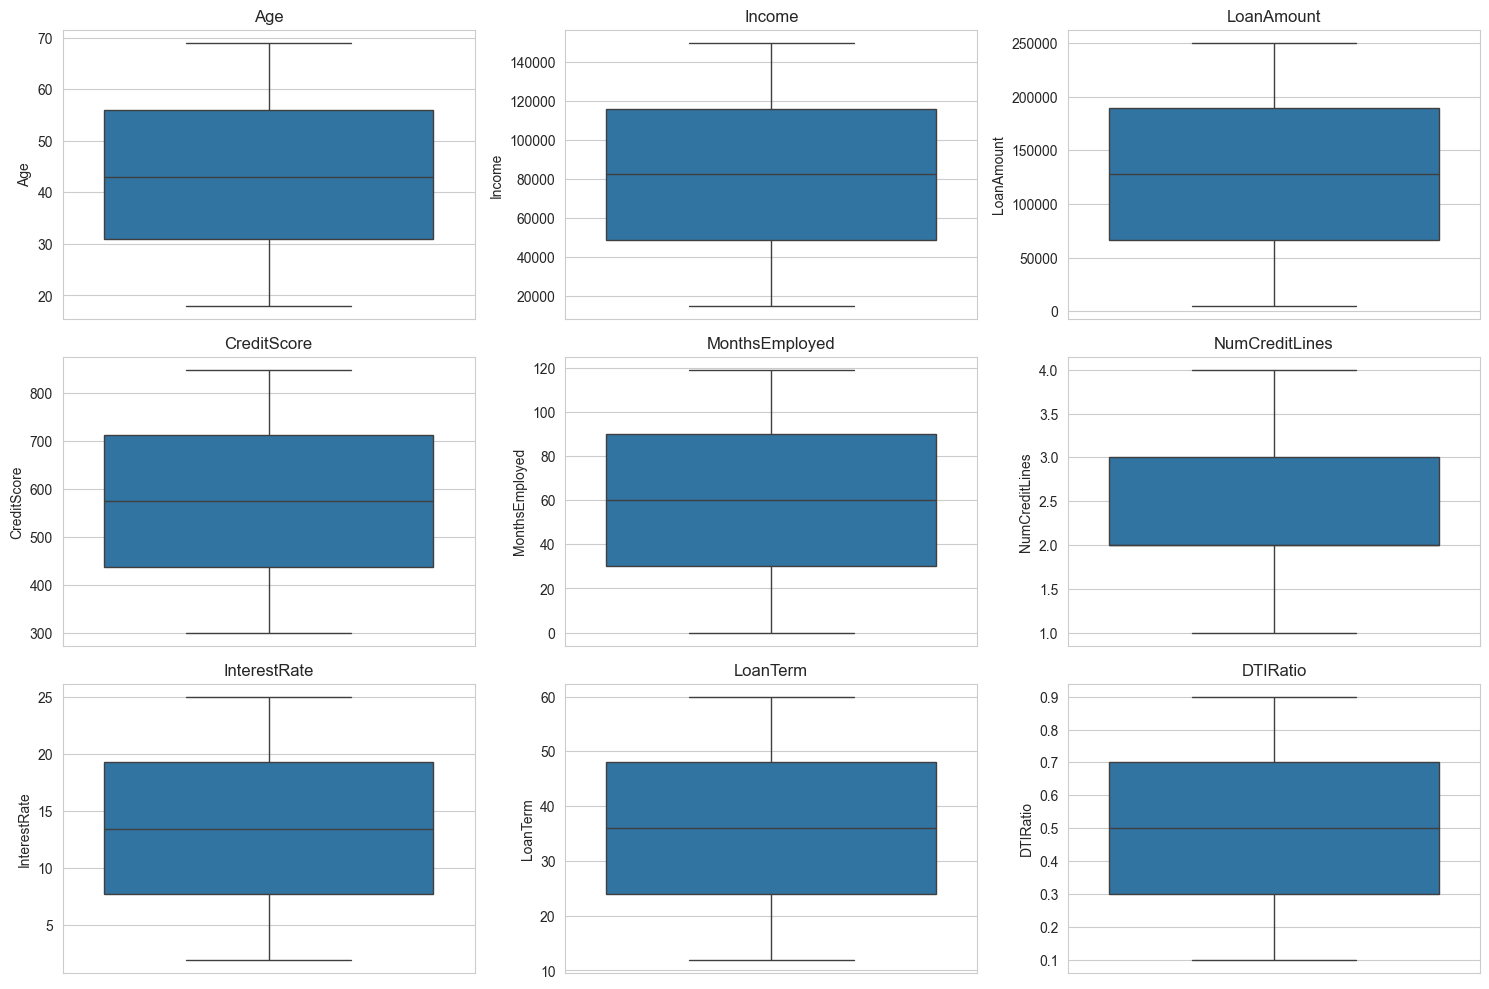

In [10]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

# Remove Loan ID

In [11]:
df_model = df.copy()

# LoanID is only an identifier and does not provide predictive information
df_model = df_model.drop(columns=["LoanID"])

df_model.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Feature Engineering

In [12]:
# 1. Loan amount relative to income
df_model["LoanToIncome"] = (
    df_model["LoanAmount"] / (df_model["Income"] + 1)
)

# 2. Estimated annual interest burden
df_model["InterestBurden"] = (
    df_model["LoanAmount"] * df_model["InterestRate"] / 100
)

# 3. Employment stability relative to age
df_model["EmploymentRatio"] = (
    df_model["MonthsEmployed"] /
    (((df_model["Age"] - 18) * 12) + 1)
)

# 4. Income available per credit line
df_model["IncomePerCreditLine"] = (
    df_model["Income"] /
    (df_model["NumCreditLines"] + 1)
)

df_model.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,LoanToIncome,InterestBurden,EmploymentRatio,IncomePerCreditLine
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,...,Divorced,Yes,Yes,Other,Yes,0,0.588255,7704.4001,0.175055,17198.80
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,...,Married,No,No,Other,Yes,0,2.467432,5985.5640,0.024470,25216.00
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,...,Divorced,Yes,Yes,Auto,No,1,1.534135,27349.0996,0.077151,21052.00
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,...,Married,No,No,Business,No,0,1.412594,3167.2893,0.000000,7928.25
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,...,Divorced,No,Yes,Auto,No,0,0.447157,594.9489,0.015842,4087.40


# Check Engineered Features

In [13]:
engineered_features = [
    "LoanToIncome",
    "InterestBurden",
    "EmploymentRatio",
    "IncomePerCreditLine"
]

df_model[engineered_features].describe()

,LoanToIncome,InterestBurden,EmploymentRatio,IncomePerCreditLine
count,255347.000000,255347.000000,255347.000000,255347.000000
mean,2.177423,17203.156130,1.550692,26458.917769
std,2.178254,13581.842064,9.445857,16251.214574
min,0.033749,106.615600,0.000000,3000.000000
25%,0.803619,6064.462100,0.096346,13925.166667
50%,1.546704,13628.926000,0.193995,23567.600000
75%,2.671710,25493.196650,0.393782,35009.583333
max,16.531360,62461.000000,119.000000,74998.500000


# Outlier Treatment

In [14]:
# Columns where extreme values can strongly affect the models
outlier_columns = [
    "Income",
    "LoanAmount",
    "InterestRate",
    "DTIRatio",
    "MonthsEmployed",
    "NumCreditLines",
    "LoanTerm"
]

# Calculate IQR limits and cap extreme values
for column in outlier_columns:

    Q1 = df_model[column].quantile(0.25)
    Q3 = df_model[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_model[column] = df_model[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Outlier treatment completed.")

Outlier treatment completed.


# Confirm Missing Values

In [15]:
print("Missing values after cleaning:")
print(df_model.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_model.duplicated().sum())

Missing values after cleaning:
0

Duplicate rows:
0


# Encode Categorical Variables

In [16]:
categorical_columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

df_model = pd.get_dummies(
    df_model,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

df_model.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,0,0,0,1,1,0,0,0,1,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,1,0,0,0,0,0,0,1,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,1,0,0,1,1,0,0,0,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,1,0,0,0,1,0,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,1,0,0,0,1,0,0,0,0,0


# Separate Features and Target

In [17]:
X = df_model.drop(columns=["Default"])
y = df_model["Default"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (255347, 28)
Target Shape: (255347,)


# Train/Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data: (204277, 28)
Testing data: (51070, 28)

Training target distribution:
Default
0    0.883873
1    0.116127
Name: proportion, dtype: float64

Testing target distribution:
Default
0    0.883865
1    0.116135
Name: proportion, dtype: float64


# Scale Data for Logistic Regression

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [20]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Random forest

In [21]:
random_forest_model = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

# Gradient Boosting

In [42]:
gradient_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

gradient_model.fit(X_train, y_train)

gradient_predictions = gradient_model.predict(X_test)
gradient_probabilities = gradient_model.predict_proba(X_test)[:, 1]

# Evaluation Function

In [23]:
def evaluate_model(name, y_true, predictions, probabilities):

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)
    roc_auc = roc_auc_score(y_true, probabilities)

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

# Compare models

In [24]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_predictions,
        gradient_probabilities
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.690425,0.228016,0.698196,0.343766,0.761521
1,Random Forest,0.885393,0.635417,0.030855,0.058852,0.739090
2,Gradient Boosting,0.886274,0.603361,0.060529,0.110021,0.758451


# Sort Model Results

In [25]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.690425,0.228016,0.698196,0.343766,0.761521
1,Gradient Boosting,0.886274,0.603361,0.060529,0.110021,0.758451
2,Random Forest,0.885393,0.635417,0.030855,0.058852,0.739090


# Detailed Classification Reports

In [26]:
print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

print("\nRANDOM FOREST")
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

print("\nGRADIENT BOOSTING")
print(
    classification_report(
        y_test,
        gradient_predictions,
        zero_division=0
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     45139
           1       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.74     51070


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.64      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.76      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070


GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.60      0.06      0.11      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.52     51070
weighted avg       0

# Best Model

In [27]:
best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model"
]

print("Best model based on ROC-AUC:", best_model_name)

Best model based on ROC-AUC: Logistic Regression


# Hyperparameter Tuning

In [63]:
rf_for_tuning = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

parameter_grid = {
    "n_estimators": [30, 50],
    "max_depth": [10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

# Use only 30,000 training rows for hyperparameter tuning
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=30000,
    random_state=42,
    stratify=y_train
)

random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=parameter_grid,
    n_iter=2,
    scoring="roc_auc",
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_tune, y_tune)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(random_search.best_score_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Parameters:
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

Best Cross-Validation ROC-AUC:
0.7291426756351341


# Tuned Model

In [50]:
tuned_model = random_search.best_estimator_

tuned_predictions = tuned_model.predict(X_test)

tuned_probabilities = tuned_model.predict_proba(X_test)[:, 1]

# Evaluate Tuned Model

In [51]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_probabilities
)

print("Tuned Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1-Score :", round(tuned_f1, 4))
print("ROC-AUC  :", round(tuned_roc_auc, 4))

Tuned Random Forest Results
--------------------------------
Accuracy : 0.7342
Precision: 0.2449
Recall   : 0.6183
F1-Score : 0.3508
ROC-AUC  : 0.7515


# Tuned Model Classification Report

In [52]:
print(
    classification_report(
        y_test,
        tuned_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.94      0.75      0.83     45139
           1       0.24      0.62      0.35      5931

    accuracy                           0.73     51070
   macro avg       0.59      0.68      0.59     51070
weighted avg       0.86      0.73      0.78     51070



# Confusion Matrix

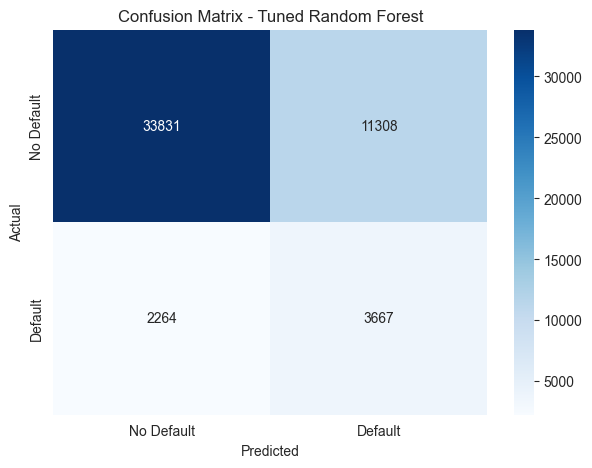

In [53]:
cm = confusion_matrix(
    y_test,
    tuned_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC Curves for All Models

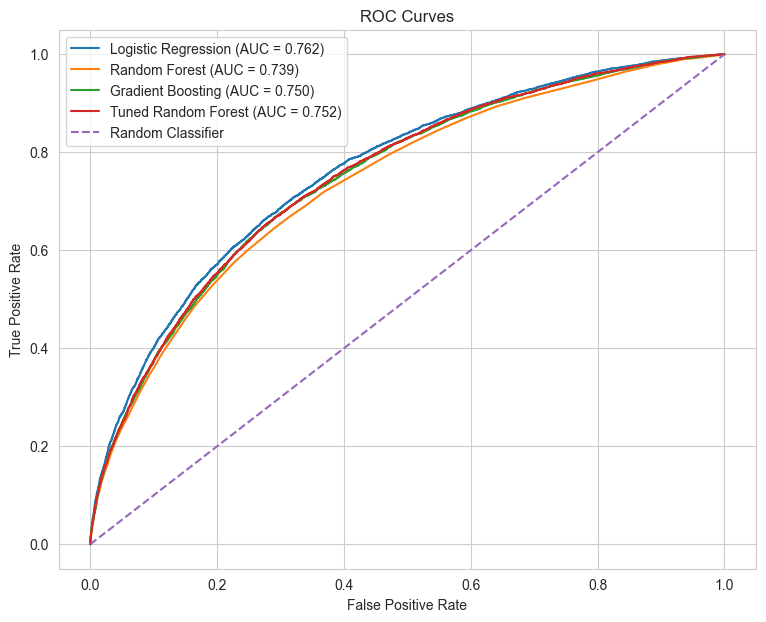

In [54]:
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probabilities
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probabilities
)

fpr_gradient, tpr_gradient, _ = roc_curve(
    y_test,
    gradient_probabilities
)

fpr_tuned, tpr_tuned, _ = roc_curve(
    y_test,
    tuned_probabilities
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, logistic_probabilities):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_probabilities):.3f})"
)

plt.plot(
    fpr_gradient,
    tpr_gradient,
    label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gradient_probabilities):.3f})"
)

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label=f"Tuned Random Forest (AUC = {tuned_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

# Feature Importance and Visualization

In [55]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Age,0.214783
6,InterestRate,0.121902
9,LoanToIncome,0.116354
10,InterestBurden,0.111594
4,MonthsEmployed,0.092358
11,EmploymentRatio,0.069234
1,Income,0.066602
12,IncomePerCreditLine,0.057861
2,LoanAmount,0.040557
3,CreditScore,0.028460


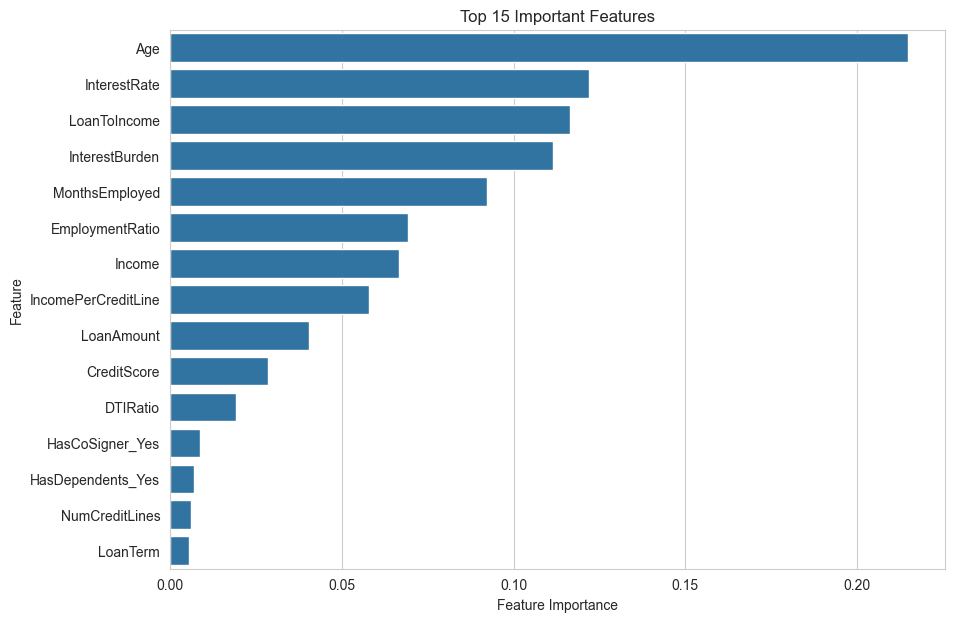

In [56]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

# Top 5 Features

In [57]:
print("Top 5 Features:")
print(feature_importance.head(5))

Top 5 Features:
           Feature  Importance
0              Age    0.214783
6     InterestRate    0.121902
9     LoanToIncome    0.116354
10  InterestBurden    0.111594
4   MonthsEmployed    0.092358


# Model Comparison Visualization

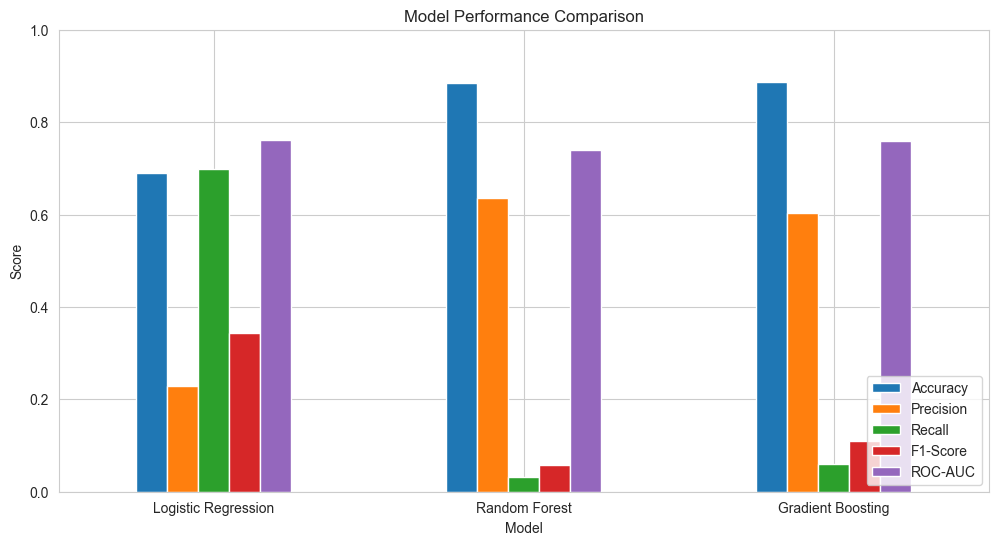

In [58]:
comparison = results_df.set_index("Model")

comparison[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

# Final Results Table

In [59]:
final_results = results_df.copy()

tuned_row = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": tuned_accuracy,
    "Precision": tuned_precision,
    "Recall": tuned_recall,
    "F1-Score": tuned_f1,
    "ROC-AUC": tuned_roc_auc
}])

final_results = pd.concat(
    [final_results, tuned_row],
    ignore_index=True
)

final_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.690425,0.228016,0.698196,0.343766,0.761521
1,Gradient Boosting,0.886274,0.603361,0.060529,0.110021,0.758451
2,Tuned Random Forest,0.734247,0.244875,0.618277,0.350808,0.751536
3,Random Forest,0.885393,0.635417,0.030855,0.058852,0.739090


# Final Findings Automatically

In [60]:
top_features = feature_importance.head(5)["Feature"].tolist()

print("FINAL FINDINGS")
print("=" * 60)

print(
    f"The dataset contains {df.shape[0]:,} loan records and "
    f"{df.shape[1]} original features."
)

print(
    f"The target variable shows {df['Default'].mean() * 100:.2f}% "
    f"of loans as defaults."
)

print(
    f"The best-performing model based on ROC-AUC was "
    f"{best_model_name} before tuning."
)

print(
    f"The tuned Random Forest achieved a ROC-AUC of "
    f"{tuned_roc_auc:.4f} on the held-out test set."
)

print(
    "The most important features in the tuned Random Forest were:"
)

for feature in top_features:
    print("-", feature)

FINAL FINDINGS
The dataset contains 255,347 loan records and 18 original features.
The target variable shows 11.61% of loans as defaults.
The best-performing model based on ROC-AUC was Logistic Regression before tuning.
The tuned Random Forest achieved a ROC-AUC of 0.7515 on the held-out test set.
The most important features in the tuned Random Forest were:
- Age
- InterestRate
- LoanToIncome
- InterestBurden
- MonthsEmployed


# Save Results and Model

In [61]:
final_results.to_csv(
    "model_evaluation_results.csv",
    index=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [62]:
import joblib

joblib.dump(
    tuned_model,
    "loan_default_random_forest.pkl"
)

joblib.dump(
    scaler,
    "logistic_scaler.pkl"
)

print("Models saved successfully.")

Models saved successfully.
